# ⚠️ V4.1 ANALYSIS & FIX (URGENT)

## Problem: v4.0 Agent Failed (51% success vs baseline 90%)
- **Root Cause**: Over-penalization paralyzed agent
- **Issues**: BETA 3.5 (2.3x too high), Action costs 0.38 (3.2x too high), Resource penalty aggressive
- **Result**: Agent afraid to act → 51% success (worse than random!)

## Solution: v4.1 Balanced Rewards
- ✅ ALPHA: 10→12 (encourage recovery)
- ✅ BETA: 3.5→2.0 (reduce resource penalty 43%)
- ✅ GAMMA: 2.5→2.0 (reduce action disruption 20%)
- ✅ EPSILON: 2.0→1.5 (reduce efficiency bonus aggressiveness)
- ✅ Scale_up: 0.38→0.25 (sweet spot, not paralyzing)
- ✅ Overhead extra penalty: 0.3→0.1 (light penalty for high resources)

## Expected v4.1: 75-85% success, upward reward trajectory, balanced actions

# RL Agent for Kubernetes Self-Healing System

## Motivation
This notebook trains a Reinforcement Learning agent to automatically recover failed Kubernetes clusters
by learning optimal actions (pod restart, scale replicas, node management) in response to system failures.

## Problem Statement
- **Goal**: Minimize MTTR (Mean Time To Recovery) for Kubernetes cluster failures
- **Challenge**: Vast action space, uncertain state transitions, trade-offs between recovery speed and resource cost
- **Solution**: RL agent learns policy π(a|s) through interaction with high-fidelity simulation environment

## 1. Environment Setup & Dependencies

In [1]:
# Install required packages
import subprocess
import sys

packages = [
    'gymnasium',
    'stable-baselines3',
    'numpy',
    'pandas',
    'seaborn',
    'matplotlib',
    'kubernetes',
    'prometheus-client',
    'pyyaml',
    'torch',
    'tensorboard'
]

for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print("✓ All dependencies installed successfully")

✓ All dependencies installed successfully


In [2]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO, DQN
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, Dict, Any
import warnings
warnings.filterwarnings('ignore')

# Configuration
np.random.seed(42)
sns.set_style('darkgrid')

print("✓ All imports loaded")

✓ All imports loaded


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 2. MDP Definition: State, Action, Reward

In [37]:
# ========== STATE SPACE DEFINITION ==========

class StateSpace:
    """Continuous and discrete state metrics from Kubernetes cluster"""
    
    # Continuous state metrics (normalized to [0, 1])
    CONTINUOUS_METRICS = {
        'cpu_utilization': (0.0, 1.0),           # Node CPU usage %
        'memory_usage': (0.0, 1.0),              # Node memory usage %
        'disk_io': (0.0, 1.0),                   # Disk I/O pressure
        'network_bandwidth': (0.0, 1.0),         # Network saturation %
        'p90_latency': (0.0, 1.0),               # API latency p90 (normalized to max 5s)
        'p99_latency': (0.0, 1.0),               # API latency p99 (normalized to max 10s)
        'error_rate_5xx': (0.0, 1.0),            # HTTP 5xx error rate
        'throughput': (0.0, 1.0),                # Requests/sec (normalized)
    }
    
    # Discrete state metrics — must match _collect_metrics() clipping ranges!
    DISCRETE_METRICS = {
        'node_ready_status': (0, 3),             # 0=all_ready, 1=partial, 2=most_down, 3=all_down
        'pending_pods': (0, 100),                # Number of pending pods
        'crashloop_flag': (0, 20),               # Count of CrashLoopBackOff pods — FIX: was (0,5), now (0,20) to match _collect_metrics
        'failed_pods': (0, 50),                  # Count of failed pods
    }
    
    @staticmethod
    def get_observation_space():
        """Define Gymnasium observation space"""
        continuous_dim = len(StateSpace.CONTINUOUS_METRICS)
        discrete_parts = []
        
        for metric, (min_val, max_val) in StateSpace.DISCRETE_METRICS.items():
            discrete_parts.append(spaces.Discrete(max_val - min_val + 1))
        
        continuous_box = spaces.Box(
            low=0.0,
            high=1.0,
            shape=(continuous_dim,),
            dtype=np.float32
        )
        
        discrete_box = spaces.MultiDiscrete(
            [max_val - min_val + 1 for _, (min_val, max_val) in StateSpace.DISCRETE_METRICS.items()]
        )
        
        return spaces.Dict({
            'continuous': continuous_box,
            'discrete': discrete_box
        })

print("✓ State space defined")
print(f"  Continuous metrics: {len(StateSpace.CONTINUOUS_METRICS)} dimensions")
print(f"  Discrete metrics: {len(StateSpace.DISCRETE_METRICS)} dimensions")
print(f"  ⚠️  FIX: crashloop_flag range updated to (0, 20) to match _collect_metrics")


✓ State space defined
  Continuous metrics: 8 dimensions
  Discrete metrics: 4 dimensions
  ⚠️  FIX: crashloop_flag range updated to (0, 20) to match _collect_metrics


In [38]:
# ========== ACTION SPACE DEFINITION ==========

class ActionSpace:
    """Kubernetes recovery actions"""
    
    ACTIONS = {
        0: {'name': 'idle', 'description': 'Do nothing, observe'},
        1: {'name': 'restart_pod', 'description': 'Kill and restart a failed pod', 'param': 'pod_index'},
        2: {'name': 'scale_up', 'description': 'Increase pod replicas by 1', 'param': 'deployment_index'},
        3: {'name': 'scale_down', 'description': 'Decrease pod replicas by 1', 'param': 'deployment_index'},
        4: {'name': 'drain_node', 'description': 'Drain node for maintenance', 'param': 'node_index'},
        5: {'name': 'cordon_node', 'description': 'Mark node as unschedulable', 'param': 'node_index'},
        6: {'name': 'uncordon_node', 'description': 'Mark node as schedulable', 'param': 'node_index'},
    }
    
    @staticmethod
    def get_action_space():
        """Define Gymnasium action space"""
        return spaces.Discrete(len(ActionSpace.ACTIONS))
    
    @staticmethod
    def describe_action(action_id: int) -> str:
        action = ActionSpace.ACTIONS.get(action_id, {'name': 'unknown'})
        return f"{action['name']}: {action.get('description', '')}"

print("✓ Action space defined")
print(f"  Total actions: {len(ActionSpace.ACTIONS)}")
for idx, action_info in ActionSpace.ACTIONS.items():
    print(f"    {idx}: {action_info['name']}")

✓ Action space defined
  Total actions: 7
    0: idle
    1: restart_pod
    2: scale_up
    3: scale_down
    4: drain_node
    5: cordon_node
    6: uncordon_node


In [ ]:
class RewardCalculator:
    """
    Optimized Reward Function (v4.1): PROGRESS-BASED + BALANCED (Fixed v4.0 over-penalization)
    
    **IMPROVEMENTS over v4.0:**
    1. ✅ REDUCED PENALTIES: BETA 3.5 → 2.0 (was paralysing agent)
    2. ✅ BALANCED ACTION COSTS: scale_up 0.38 → 0.25 (still penalized but viable)
    3. ✅ INCREASED HEALTH REWARD: ALPHA 10.0 → 12.0 (encourage recovery attempts)
    4. ✅ RESOURCE EFFICIENCY: Still enabled but not over-penalizing
    5. ✅ ACTION DIVERSITY: Bonus if multiple actions used, penalty if one dominates
    
    Principle: Recovery > Efficiency > Diversity (hierarchical: recovery must succeed first!)
    R(s_t, a_t) = ΔHealth_Progress + Resource_Efficiency - SLA_Penalty - Balanced_Action_Cost
    """
    
    # ── TUNED WEIGHTS (v6.0 - Speed optimization after excellent 86% baseline) ────────────────────────
    ALPHA = 7.0         # Health improvement reward (INCREASED from 4.0 → 7.0): Prioritize fast recovery
    EPSILON = 3.0       # Resource efficiency bonus (INCREASED from 1.5 → 3.0): Balance recovery
    BETA = 3.0          # Resource overhead penalty (INCREASED from 2.0 → 3.0): Penalize waste more
    GAMMA = 3.0         # Action disruption penalty (INCREASED from 2.0 → 3.0): Balance cost
    DELTA = 2.0         # SLA violation penalty (REDUCED from 4.0 → 2.0): SLA is secondary
    STEP_PENALTY = 0.06 # Time cost per step (INCREASED from 0.04 → 0.06): Penalize slow recovery
    RECOVERY_BONUS = 50.0    # Success bonus: Keep high
    COLLAPSE_PENALTY = -60.0 # Failure penalty: Keep strong
    ACTION_DIVERSITY_BONUS = 1.0  # ACTION DIVERSITY: Reduced from 1.5 (was too aggressive)
    
    @staticmethod
    def calculate(prev_state: Dict[str, Any], curr_state: Dict[str, Any], 
                  action_id: int, episode_steps: int, action_distribution: Dict[int, float] = None) -> float:
        """
        Calculate reward for transition (s_t, a_t, s_{t+1})
        
        **v4.0 FORMULA (PROGRESS-BASED):**
        R = ΔHealth_Progress + Resource_Efficiency - Penalties
        
        This makes reward INCREASE when making progress (upward trajectory)
        instead of always negative (v3.0 style)
        """
        
        # === 1. HEALTH PROGRESS (Primary reward) ===
        prev_health = RewardCalculator._calculate_health(prev_state)
        curr_health = RewardCalculator._calculate_health(curr_state)
        health_improvement = curr_health - prev_health  # Can be POSITIVE!
        stability_reward = RewardCalculator.ALPHA * health_improvement  # Progressive
        
        # === 2. RESOURCE EFFICIENCY (Bonus for good decisions) ===
        resource_efficiency = RewardCalculator._calculate_resource_efficiency(curr_state)
        efficiency_bonus = RewardCalculator.EPSILON * resource_efficiency  # NEW
        
        # === 3. RESOURCE OVERHEAD PENALTY (Increased to discourage waste) ===
        overhead_cost = RewardCalculator._calculate_overhead(curr_state)
        overhead_penalty = RewardCalculator.BETA * overhead_cost  # INCREASED from 1.5 to 3.5
        
        # === 4. ACTION COST (Balanced - no single action dominates) ===
        action_disruption = RewardCalculator._get_action_impact(action_id)
        impact_penalty = RewardCalculator.GAMMA * action_disruption
        
        # === 5. SLA PROTECTION ===
        sla_penalty = RewardCalculator._calculate_sla_penalty(curr_state)
        sla_cost = RewardCalculator.DELTA * sla_penalty
        
        # === 6. ACTION DIVERSITY BONUS (NEW - encourage balanced actions) ===
        diversity_bonus = 0.0
        if action_distribution is not None:
            diversity_bonus = RewardCalculator._calculate_action_diversity_bonus(action_distribution)
        
        # === 7. TIME PENALTY ===
        step_penalty = RewardCalculator.STEP_PENALTY
        
        # === 8. NEW v5.1: STEADY STATE LOGIC (reward inaction in healthy state, penalize risky actions) ===
        steady_state_bonus = 0.0
        unnecessary_action_penalty = 0.0
        
        is_system_healthy = RewardCalculator._is_system_healthy(curr_state)
        
        if is_system_healthy:
            # Reward for doing nothing (idle) when system is fine
            if action_id == 0:
                steady_state_bonus = 3.0  # Strong reward for idle in healthy state
            # Penalize risky actions (scale_up, drain) when system doesn't need intervention
            elif action_id in [2, 4]:  # scale_up, drain_node
                unnecessary_action_penalty = -8.0  # Heavy penalty for unnecessary disruption
        
        # **v5.1 FORMULA: Added steady state logic to prevent action bias**
        reward = (stability_reward + efficiency_bonus + diversity_bonus + steady_state_bonus -
                  overhead_penalty - impact_penalty - sla_cost - step_penalty - unnecessary_action_penalty)
        
        return float(reward)

    @staticmethod
    def _calculate_health(state: Dict[str, Any]) -> float:
        """K8s-aligned health score [0,1]: Prioritize SLA metrics.
        
        Weights (K8s priorities): error_rate(30%) + node(25%) + latency(20%) + pending(10%) + throughput(10%) + crashloop(5%)
        """
        error_rate = state.get('error_rate_5xx', 0)
        pending_pods = state.get('pending_pods', 0) / 100.0
        crashloop = state.get('crashloop_flag', 0) / 20.0
        node_status = state.get('node_ready_status', 0) / 3.0
        latency = (state.get('p90_latency', 0) + state.get('p99_latency', 0)) / 2.0
        throughput_loss = 1.0 - state.get('throughput', 1.0)
        
        # Detect critical resource exhaustion
        cpu = state.get('cpu_utilization', 0)
        memory = state.get('memory_usage', 0)
        critical_resource = (cpu > 0.98 or memory > 0.98)
        
        # K8s-aligned health calculation (prioritize SLA metrics)
        health = (
            (1.0 - error_rate) * 0.30 +         # 30%: Error rate is PRIMARY SLA signal
            (1.0 - node_status) * 0.25 +        # 25%: Node health = availability
            (1.0 - latency) * 0.20 +            # 20%: Latency = user experience
            (1.0 - pending_pods) * 0.10 +       # 10%: Pending pods indicator
            (1.0 - throughput_loss) * 0.10 +    # 10%: Throughput
            (1.0 - crashloop) * 0.05            # 5%: CrashLoop low priority
        )
        
        # Penalize critical resource exhaustion
        if critical_resource:
            health *= 0.5
        
        return float(np.clip(health, 0, 1))
    
    @staticmethod
    def _calculate_resource_efficiency(state: Dict[str, Any]) -> float:
        """
        NEW v4.0: Reward efficient resource usage
        
        Efficiency = high_performance_with_low_resources
        Bonus when: good metrics (low error, good throughput) with low resource use
        """
        error_rate = state.get('error_rate_5xx', 0)
        throughput = state.get('throughput', 1.0)
        cpu = state.get('cpu_utilization', 0)
        memory = state.get('memory_usage', 0)
        
        # Efficiency: good performance (low error, high throughput) with low resources
        performance = (1.0 - error_rate) * throughput  # Good performance indicator
        resource_usage = (cpu + memory) / 2.0  # Low resource indicator
        
        # If performance is good AND resources are low: high efficiency bonus
        if resource_usage < 0.5:  # Resources <50% = efficient
            efficiency = performance * (1.0 - resource_usage)  # High bonus
        else:
            efficiency = 0.0  # No bonus if resources > 50%
        
        return float(np.clip(efficiency, 0, 1))
    
    @staticmethod
    def _calculate_overhead(state: Dict[str, Any]) -> float:
        """
        UPDATED v4.1: Reduced penalty for resource usage (fix v4.0 over-penalization)
        
        v4.0: extra_penalty = 0.3 when avg_resources > 0.7 (paralysing!)
        v4.1: extra_penalty = 0.1 when avg_resources > 0.7 (balanced)
        
        Strategy: Still penalize waste, but allow recovery actions during high-load scenarios
        """
        cpu = state.get('cpu_utilization', 0)
        memory = state.get('memory_usage', 0)
        network = state.get('network_bandwidth', 0)
        
        # Average resource usage
        avg_resources = (cpu + memory + network) / 3.0
        
        # Light penalty if resources > 70% (inefficient scaling_up)
        if avg_resources > 0.7:
            penalty = avg_resources + 0.1  # REDUCED from 0.3→0.1 (was too aggressive)
        else:
            penalty = avg_resources * 0.8  # Light reduction for normal resources
        
        return float(np.clip(penalty, 0, 1))
    
    @staticmethod
    def _get_action_impact(action_id: int) -> float:
        """
        TUNED v5.1: Action costs to prevent continuous scale_up bias (fix action bias)
        
        Problem: Agent learns scale_up works → keeps doing it even when not needed
        Solution: Increase scale_up cost significantly + add idle reward logic
        
        v4.1 ratio: drain/scale_up = 0.70/0.25 = 2.8x (still biased to scale_up!)
        v5.1 ratio: drain/scale_up = 0.70/0.45 = 1.56x (finally balanced, scale_up costly!)
        """
        action_impacts = {
            0: 0.0,     # idle (FREE - encourage inaction in healthy state)
            1: 0.45,    # restart_pod (MEDIUM - pod downtime)
            2: 0.45,    # scale_up (↑↑↑ INCREASED from 0.25→0.45: MUCH more expensive!)
            3: 0.28,    # scale_down (unchanged)
            4: 0.70,    # drain_node (keep same - most disruptive)
            5: 0.42,    # cordon_node (unchanged)
            6: 0.08,    # uncordon_node (keep same - cheapest)
        }
        return action_impacts.get(action_id, 0.25)
    
    @staticmethod
    def _is_system_healthy(state: Dict[str, Any]) -> bool:
        """NEW v5.1: Detect if system is in healthy state (no intervention needed).
        
        Criteria: Low error rate + manageable load + no critical issues
        This enables the agent to learn when to take action vs. when to be idle.
        """
        return (
            state['error_rate_5xx'] < 0.08 and
            state['cpu_utilization'] < 0.75 and
            state['memory_usage'] < 0.75 and
            state['pending_pods'] < 5 and
            state['node_ready_status'] < 1.0
        )
    
    @staticmethod
    def _calculate_sla_penalty(state: Dict[str, Any]) -> float:
        """Strict K8s SLA penalty: Exponential (early warning).
        
        Thresholds: latency 0.3 (strict), p90 0.25, error_rate 0.02 (very strict)
        """
        p99_latency = state.get('p99_latency', 0)
        p90_latency = state.get('p90_latency', 0)
        error_rate = state.get('error_rate_5xx', 0)
        
        # Exponential penalties for SLA violations
        latency_violation = max(0, p99_latency - 0.3) ** 1.5 * 1.0
        latency_p90_violation = max(0, p90_latency - 0.25) ** 1.3 * 0.5
        error_violation = max(0, error_rate - 0.02) ** 1.2 * 1.0
        
        penalty = min(1.0, latency_violation + latency_p90_violation + error_violation)
        return penalty
    
    @staticmethod
    def _calculate_action_diversity_bonus(action_distribution: Dict[int, float]) -> float:
        """
        NEW v4.0: Bonus for diverse action usage (not single-action dominated)
        
        Penalize: One action > 90% → bonus = 0 (no diversity)
        Reward: Balanced distribution → bonus = 1.5 (good diversity)
        """
        # Find max action percentage
        if not action_distribution:
            return 0.0
        
        max_action_pct = max(action_distribution.values())
        
        # If one action >90%: NO diversity bonus (and minor penalty in main)
        if max_action_pct > 0.90:
            return -0.5  # Penalty for dominating action
        # If balanced (no action >50%): Full diversity bonus
        elif max_action_pct < 0.50:
            return 1.5  # Full bonus - nice balance
        # If moderate (50-70%): Partial bonus
        elif max_action_pct < 0.70:
            return 0.8  # Partial bonus
        # If somewhat concentrated (70-90%): Small bonus
        else:
            return 0.2

print("✅ Reward Function v4.0: PROGRESS-BASED + BALANCED ACTIONS + RESOURCE-AWARE")
print(f"\n🎯 KEY IMPROVEMENTS:")
print(f"  1. ✅ UPWARD TRAJECTORY: Rewards positive health progress (can be >0)")
print(f"  2. ✅ BALANCED ACTIONS: scale_up cost 0.12 → 0.38 (3.2x), drain 0.75 → 0.70")
print(f"  3. ✅ RESOURCE EFFICIENCY: Bonus for good perf + low resources")
print(f"  4. ✅ ACTION DIVERSITY: Bonus if multiple actions used, penalty if dominated")
print(f"\n📊 WEIGHTS (v4.0):")
print(f"  ALPHA (Recovery):       {RewardCalculator.ALPHA}  (up from 8.0)")
print(f"  EPSILON (Efficiency):   {RewardCalculator.EPSILON} (NEW - resource bonus)")
print(f"  BETA (Overhead):        {RewardCalculator.BETA}   (up from 1.5 - penalize waste)")
print(f"  GAMMA (Disruption):     {RewardCalculator.GAMMA}  (was 2.0)")
print(f"  DELTA (SLA):            {RewardCalculator.DELTA}  (keep strict)")
print(f"  ACTION_DIVERSITY_BONUS: {RewardCalculator.ACTION_DIVERSITY_BONUS} (NEW)")
print(f"\n⚡ ACTION COSTS (NEW - More Balanced):")
print(f"  idle:        0.00  (free but risky)")
print(f"  restart_pod: 0.48  (medium risk)")
print(f"  scale_up:    0.38  (↑UP from 0.12 - reduce bias!)")
print(f"  scale_down:  0.30")
print(f"  drain_node:  0.70  (↓DOWN from 0.75 - more balanced)")
print(f"  cordon:      0.45")
print(f"  uncordon:    0.08")
print(f"\n🎯 Expected v4.0: Success 88-92%, More diverse actions, Better resource efficiency, Upward reward trend")


✅ Reward Function v4.0: PROGRESS-BASED + BALANCED ACTIONS + RESOURCE-AWARE

🎯 KEY IMPROVEMENTS:
  1. ✅ UPWARD TRAJECTORY: Rewards positive health progress (can be >0)
  2. ✅ BALANCED ACTIONS: scale_up cost 0.12 → 0.38 (3.2x), drain 0.75 → 0.70
  3. ✅ RESOURCE EFFICIENCY: Bonus for good perf + low resources
  4. ✅ ACTION DIVERSITY: Bonus if multiple actions used, penalty if dominated

📊 WEIGHTS (v4.0):
  ALPHA (Recovery):       12.0  (up from 8.0)
  EPSILON (Efficiency):   1.5 (NEW - resource bonus)
  BETA (Overhead):        2.0   (up from 1.5 - penalize waste)
  GAMMA (Disruption):     2.0  (was 2.0)
  DELTA (SLA):            4.0  (keep strict)
  ACTION_DIVERSITY_BONUS: 1.0 (NEW)

⚡ ACTION COSTS (NEW - More Balanced):
  idle:        0.00  (free but risky)
  restart_pod: 0.48  (medium risk)
  scale_up:    0.38  (↑UP from 0.12 - reduce bias!)
  scale_down:  0.30
  drain_node:  0.70  (↓DOWN from 0.75 - more balanced)
  cordon:      0.45
  uncordon:    0.08

🎯 Expected v4.0: Success 88-92%

## 3. Kubernetes Self-Healing Environment

In [ ]:
# Function to monitor training progress
def monitor_training(env, model, max_steps=10000):
    losses = []
    for step in range(max_steps):
        # Simulate training step
        loss = np.random.random()  # Replace with actual loss from model
        losses.append(loss)
        
        # Print progress every 100 steps
        if step % 100 == 0:
            print(f"Step {step}: Loss = {loss:.4f}")
        
        # Simulate stopping condition
        if step == 5000:  # Example stopping condition
            print(f"Stopping training at step {step}")
            break
        
        time.sleep(0.1)  # Simulate time delay for training step
    
    print("Training completed.")
    return losses

In [44]:
    # ── Minimally tuned action effects ──────────────────────────────────────
    def _execute_action(self, action: int, action_name: str) -> None:
        """Modify state in-place according to action and current failure scenario."""
        s = self.current_state
        scenario = self.current_scenario  # e.g., 'node_failure', 'pod_crash_loop', etc.
        
        if action == 1:   # restart_pod
            # Nearly same as original, just very slight reduction
            multiplier = 5.5 if scenario == 'pod_crash_loop' else 1.8
            s['crashloop_flag'] = max(0, s['crashloop_flag'] - multiplier)
            s['failed_pods']    = max(0, s['failed_pods']    - multiplier)
            s['pending_pods']   = max(0, s['pending_pods']   - 2)
            s['error_rate_5xx'] = max(0, s['error_rate_5xx'] * (0.72 if scenario == 'pod_crash_loop' else 0.88))
            s['throughput']     = min(1.0, s['throughput'] + 0.04)
            
        elif action == 2:  # scale_up
            # Slight improvement
            multiplier = 0.16 if scenario == 'resource_exhaustion' else 0.085
            s['pending_pods']   = max(0, s['pending_pods'] - 6)
            s['throughput']     = min(1.0, s['throughput'] + multiplier)
            s['cpu_utilization']= max(0.05, s['cpu_utilization'] - 0.085)
            s['memory_usage']   = max(0.05, s['memory_usage'] - 0.085)
            s['error_rate_5xx'] = max(0, s['error_rate_5xx'] * 0.91)
            
        elif action == 3:  # scale_down
            # Keep same
            s['cpu_utilization']= max(0.05, s['cpu_utilization'] - 0.05)
            s['memory_usage']   = max(0.05, s['memory_usage']    - 0.05)
            s['throughput']    *= 0.90
            
        elif action == 4:  # drain_node
            # Very slight improvement
            effect = 8.2 if scenario == 'node_failure' else 3.1
            s['node_ready_status'] = max(0, s['node_ready_status'] - 1.0)
            s['pending_pods']      = min(100, s['pending_pods'] + effect)
            
        elif action == 5:  # cordon_node
            # Keep same
            effect = 1.0 if scenario == 'node_failure' else 0.5
            s['node_ready_status'] = max(0, s['node_ready_status'] - effect)
            s['error_rate_5xx']    = max(0, s['error_rate_5xx'] * 0.95)
            
        elif action == 6:  # uncordon_node
            # Very slight improvement
            if scenario == 'node_failure':
                s['node_ready_status'] = max(0, s['node_ready_status'] - 1.6)
                s['pending_pods']      = max(0, s['pending_pods'] - 16)
            else:
                s['node_ready_status'] = max(0, s['node_ready_status'] - 0.6)
                s['pending_pods']      = max(0, s['pending_pods'] - 3)
            s['error_rate_5xx']   = max(0, s['error_rate_5xx'] * 0.96)
            s['throughput']       = min(1.0, s['throughput'] + 0.025)
            
        # action == 0 (idle): no change


In [45]:
# ========== FAILURE SCENARIOS ==========

class FailureScenario:
    """Realistic Kubernetes failure patterns for agent training."""

    SCENARIOS = {
        'node_failure': {
            'description': 'Node down / network partition',
            'state': {
                'cpu_utilization': 0.2,
                'memory_usage': 0.1,
                'disk_io': 0.05,
                'network_bandwidth': 0.05,
                'p90_latency': 0.8,
                'p99_latency': 0.95,
                'error_rate_5xx': 0.30,
                'throughput': 0.2,
                'node_ready_status': 3.0,
                'pending_pods': 60.0,
                'crashloop_flag': 0.0,
                'failed_pods': 30.0,
            },
        },
        'pod_crash_loop': {
            'description': 'CrashLoopBackOff - app bug',
            'state': {
                'cpu_utilization': 0.3,
                'memory_usage': 0.4,
                'disk_io': 0.1,
                'network_bandwidth': 0.2,
                'p90_latency': 0.4,
                'p99_latency': 0.5,
                'error_rate_5xx': 0.15,
                'throughput': 0.5,
                'node_ready_status': 0.0,
                'pending_pods': 5.0,
                'crashloop_flag': 12.0,
                'failed_pods': 8.0,
            },
        },
        'resource_exhaustion': {
            'description': 'High CPU/Memory pressure',
            'state': {
                'cpu_utilization': 0.95,
                'memory_usage': 0.90,
                'disk_io': 0.7,
                'network_bandwidth': 0.5,
                'p90_latency': 0.6,
                'p99_latency': 0.75,
                'error_rate_5xx': 0.05,
                'throughput': 0.3,
                'node_ready_status': 1.0,
                'pending_pods': 25.0,
                'crashloop_flag': 2.0,
                'failed_pods': 5.0,
            },
        },
        'network_degradation': {
            'description': 'High latency / packet loss',
            'state': {
                'cpu_utilization': 0.5,
                'memory_usage': 0.4,
                'disk_io': 0.2,
                'network_bandwidth': 0.85,
                'p90_latency': 0.9,
                'p99_latency': 1.0,
                'error_rate_5xx': 0.20,
                'throughput': 0.4,
                'node_ready_status': 0.0,
                'pending_pods': 10.0,
                'crashloop_flag': 3.0,
                'failed_pods': 4.0,
            },
        },
    }

    @staticmethod
    def sample_scenario() -> Dict[str, Any]:
        """Randomly sample a failure scenario with noise."""
        scenario_name = np.random.choice(list(FailureScenario.SCENARIOS.keys()))
        scenario = FailureScenario.SCENARIOS[scenario_name].copy()
        scenario['name'] = scenario_name
        
        state = scenario['state'].copy()
        for key, val in state.items():
            noise = np.random.uniform(-0.08, 0.08)
            # Respect natural ranges for discrete metrics
            if key in ['node_ready_status', 'pending_pods', 'crashloop_flag', 'failed_pods']:
                max_vals = {'node_ready_status': 3, 'pending_pods': 100, 'crashloop_flag': 20, 'failed_pods': 50}
                state[key] = float(np.clip(val + noise * max_vals.get(key, 1), 0, max_vals.get(key, 1)))
            else:
                state[key] = float(np.clip(val + noise, 0.0, 1.0))
        
        scenario['state'] = state
        return scenario

print("✓ Failure scenarios defined (4 types)")
for name, s in FailureScenario.SCENARIOS.items():
    print(f"  {name}: {s['description']}")


✓ Failure scenarios defined (4 types)
  node_failure: Node down / network partition
  pod_crash_loop: CrashLoopBackOff - app bug
  resource_exhaustion: High CPU/Memory pressure
  network_degradation: High latency / packet loss


In [ ]:
# ========== KUBERNETES SELF-HEALING ENVIRONMENT ==========

class K8sSelfHealingEnv(gym.Env):
    """Gymnasium environment for Kubernetes self-healing RL agent.
    
    Design: Agent learns from observations ONLY, not from scenario names.
    Action effects are UNIFORM across all scenarios.
    This ensures generalizability to production where scenarios are unknown.
    """
    
    metadata = {'render_modes': ['human']}
    
    def __init__(self, config: Dict[str, Any] = None):
        super(K8sSelfHealingEnv, self).__init__()
        
        self.config = config or {}
        self.max_steps = self.config.get('max_steps', 100)
        self.observation_step_interval = self.config.get('step_interval_sec', 10)
        self.num_deployments = self.config.get('num_deployments', 5)
        self.num_nodes = self.config.get('num_nodes', 3)
        
        self.observation_space = spaces.Box(
            low=0.0,
            high=1.0,
            shape=(12,),  # 8 continuous + 4 discrete (normalized to [0,1])
            dtype=np.float32
        )
        self.action_space = ActionSpace.get_action_space()
        
        self.current_step = 0
        self.episode_rewards = []
        self.current_state = None
        self.prev_state = None
        self._scenario_name = None  # For logging/diagnostics only, NOT used in action dynamics
    
    def reset(self, seed=None, options=None):
        """Reset: inject initial failure via scenario sampling.
        
        NOTE: Scenario is only used for initialization diversity.
        Agent learns from observations, NOT from scenario names.
        """
        super().reset(seed=seed)
        self.current_step = 0
        self.episode_rewards = []
        self.current_state = self._generate_failed_state()
        self.prev_state = self.current_state.copy()
        obs = self._encode_observation(self.current_state)
        return obs, {}
    
    def step(self, action: int) -> Tuple[np.ndarray, float, bool, bool, Dict]:
        """Execute one recovery action and observe new state."""
        self.current_step += 1
        
        # 1. Apply action effects to state (UNIFORM, not scenario-aware)
        action_name = ActionSpace.ACTIONS[action]['name']
        self._execute_action(action, action_name)
        
        # 2. Natural recovery + noise (applied AFTER action effects)
        self.prev_state = self.current_state.copy()
        self.current_state = self._collect_metrics()
        
        # 3. Reward
        reward = RewardCalculator.calculate(
            self.prev_state, self.current_state, action, self.current_step
        )
        self.episode_rewards.append(reward)
        
        # 4. Termination
        recovered  = self._is_recovered()
        collapsed  = self._is_collapsed()
        truncated  = self.current_step >= self.max_steps
        terminated = recovered or collapsed
        
        obs = self._encode_observation(self.current_state)
        info = {
            'action': action_name,
            'recovered': recovered,
            'collapsed': collapsed,
            'episode_reward': sum(self.episode_rewards),
        }
        return obs, reward, terminated, truncated, info
    
    def _generate_failed_state(self) -> Dict[str, float]:
        """Generate initial failed state from a sampled scenario.
        
        Scenario is ONLY for initialization randomness, not used in action dynamics.
        """
        scenario = FailureScenario.sample_scenario()
        self._scenario_name = scenario['name']
        return scenario['state'].copy()

    # ── Action effects: UNIFORM (no scenario-awareness) ───────────────────────
    def _execute_action(self, action: int, action_name: str) -> None:
        """Modify state in-place. Effects are UNIFORM, observation-based.
        
        Design principle: Agent makes decisions based on current metrics,
        not on knowing which scenario is active. This ensures the learned policy
        generalizes to production environments where scenario types are unknown.
        """
        s = self.current_state
        
        if action == 1:   # restart_pod
            s['crashloop_flag'] = max(0, s['crashloop_flag'] - 2.0)
            s['failed_pods']    = max(0, s['failed_pods']    - 2.0)
            s['pending_pods']   = max(0, s['pending_pods']   - 2.0)
            s['error_rate_5xx'] = max(0, s['error_rate_5xx'] * 0.85)
            s['throughput']     = min(1.0, s['throughput'] + 0.04)
            
        elif action == 2:  # scale_up
            s['pending_pods']   = max(0, s['pending_pods'] - 6.0)
            s['throughput']     = min(1.0, s['throughput'] + 0.10)
            s['cpu_utilization']= max(0.05, s['cpu_utilization'] - 0.08)
            s['memory_usage']   = max(0.05, s['memory_usage'] - 0.08)
            s['error_rate_5xx'] = max(0, s['error_rate_5xx'] * 0.91)
            
        elif action == 3:  # scale_down
            s['cpu_utilization']= max(0.05, s['cpu_utilization'] - 0.05)
            s['memory_usage']   = max(0.05, s['memory_usage']    - 0.05)
            s['throughput']    *= 0.90
            
        elif action == 4:  # drain_node
            s['node_ready_status'] = max(0, s['node_ready_status'] - 1.0)
            s['pending_pods']      = min(100, s['pending_pods'] + 5.0)
            
        elif action == 5:  # cordon_node
            s['node_ready_status'] = max(0, s['node_ready_status'] - 0.8)
            s['error_rate_5xx']    = max(0, s['error_rate_5xx'] * 0.95)
            
        elif action == 6:  # uncordon_node
            s['node_ready_status'] = max(0, s['node_ready_status'] - 0.8)
            s['pending_pods']      = max(0, s['pending_pods'] - 5.0)
            s['error_rate_5xx']   = max(0, s['error_rate_5xx'] * 0.96)
            s['throughput']       = min(1.0, s['throughput'] + 0.025)

    def _collect_metrics(self) -> Dict[str, float]:
        """Simulate post-action metric collection with natural recovery (improved v3.0).
        
        IMPROVEMENT: Changed drift from 0.95 to 0.98 for more realistic recovery
        0.95 = very slow recovery (needs many steps)
        0.98 = realistic recovery (balanced with action effects)
        """
        state = {}
        for key, val in self.current_state.items():
            if key == 'node_ready_status':
                # Nodes recover slowly but naturally
                drift = max(0, val - np.random.uniform(0, 0.12))
                state[key] = float(np.clip(drift + np.random.normal(0, 0.05), 0, 3))
            elif key == 'pending_pods':
                # Pending pods clear gradually due to reconciliation
                drift = max(0, val - np.random.uniform(0.8, 2.5))
                state[key] = float(np.clip(drift + np.random.normal(0, 0.3), 0, 100))
            elif key == 'crashloop_flag':
                # CrashLoop pods recover with K8s self-healing
                drift = max(0, val - np.random.uniform(0.5, 1.8))
                state[key] = float(np.clip(drift + np.random.normal(0, 0.2), 0, 20))
            elif key == 'failed_pods':
                # Failed pods recover with self-healing
                drift = max(0, val - np.random.uniform(0.5, 1.8))
                state[key] = float(np.clip(drift + np.random.normal(0, 0.2), 0, 50))
            else:
                # Other metrics (CPU, latency, error_rate) recover to normal baseline
                # TUNED v5.0: 0.98→0.90 forces agent to take action (natural recovery less strong)
                target = np.random.uniform(0.08, 0.25)
                drift  = val * 0.90 + target * 0.10
                state[key] = float(np.clip(drift + np.random.normal(0, 0.015), 0, 1))
        return state

    def _is_recovered(self) -> bool:
        """True when health thresholds met (RELAXED v5.0 to enable learning)."""
        s = self.current_state
        return (
            s['error_rate_5xx']    < 0.05 and  # Relaxed: 0.02 → 0.05
            (s['pending_pods']     < 3    or   # OR logic: easier to achieve
             s['crashloop_flag']   < 0.5) and # Relaxed: 1 → 0.5
            s['node_ready_status'] < 1
        )

    def _is_collapsed(self) -> bool:
        """True when cluster is unrecoverable."""
        s = self.current_state
        return s['error_rate_5xx'] > 0.5 and s['node_ready_status'] >= 3

    def _encode_observation(self, state: Dict[str, float]) -> np.ndarray:
        """Flatten state to normalized [0,1]^12 observation vector."""
        continuous = np.array([
            state['cpu_utilization'],
            state['memory_usage'],
            state['disk_io'],
            state['network_bandwidth'],
            state['p90_latency'],
            state['p99_latency'],
            state['error_rate_5xx'],
            state['throughput'],
        ], dtype=np.float32)
        
        discrete = np.array([
            state['node_ready_status'] / 3,
            state['pending_pods']      / 100,
            state['crashloop_flag']    / 20,
            state['failed_pods']       / 50,
        ], dtype=np.float32)
        
        return np.clip(np.concatenate([continuous, discrete]), 0.0, 1.0)

print("✓ K8sSelfHealingEnv defined (observation-based, uniform action effects)")


✓ K8sSelfHealingEnv defined (observation-based, uniform action effects)


## 4. Environment Validation

In [ ]:
from stable_baselines3.common.env_checker import check_env
# Create and validate environment
env_config = {
    'max_steps': 150,            # ↑ TĂNG từ 100 → 150 (more time for agent to find optimal recovery)
    'step_interval_sec': 10,
    'num_deployments': 5,
    'num_nodes': 3,
}

env = K8sSelfHealingEnv(config=env_config)

# Check environment compatibility with Gymnasium
check_env(env)
print("✓ Environment passes Gymnasium validation")

# Test basic functionality
obs, info = env.reset()
print(f"✓ Initial observation shape: {obs.shape}")
print(f"  Observation: {obs[:4]}... (showing first 4 dims)")

# Test random rollout
for _ in range(5):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    print(f"  Step: {info['action']:15s} | Reward: {reward:6.3f} | Recovered: {info['recovered']}")
    if terminated:
        break

✓ Environment passes Gymnasium validation
✓ Initial observation shape: (12,)
  Observation: [0.3568737  0.43258527 0.09586781 0.13565347]... (showing first 4 dims)
  Step: cordon_node     | Reward: -1.675 | Recovered: False
  Step: cordon_node     | Reward: -1.672 | Recovered: False
  Step: scale_down      | Reward: -1.227 | Recovered: False
  Step: uncordon_node   | Reward: -0.612 | Recovered: False
  Step: scale_down      | Reward: -0.966 | Recovered: False


## 5. Training Setup & Agent Initialization

In [ ]:
training_config = {
    'algorithm': 'PPO',
    'total_timesteps': 250000,
    'learning_rate': 3e-4,      # ✓ GIỮA NGUYÊN: 3e-4 (ổn định tốt)
    'n_steps': 4096,             # ↑ TĂNG từ 2048 → 4096 (larger batch for stability)
    'batch_size': 64,            # ✓ GIỮA NGUYÊN: 64 (good balance)
    'gamma': 0.999,              # ↑ TĂNG từ 0.99 → 0.999 (long-term rewards, reduce spikes)
    'gae_lambda': 0.95,
    'ent_coef': 0.05,            # ↓ GIẢM từ 0.05 → 0.02 (reduce random exploration noise)
    'clip_range': 0.2,           # PPO clip parameter
}

# Create environment
env = K8sSelfHealingEnv(config=env_config)

print(f"✓ Environment created")
print(f"  Max steps: {env_config['max_steps']}")
print(f"  Observation space: {env.observation_space}")
print(f"  Action space: {env.action_space}")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
✓ Agent initialized with PPO
  Strategy: Conservative reward + fine-tuned entropy
  Total timesteps: 250000
  Entropy coef: 0.03 (sweet spot)
  Expected: Diverse policy + higher success rate


## 6. Training Loop

In [ ]:
# Train agent
print(f"Starting training for {training_config['total_timesteps']:,} timesteps...\n")
print(f"📊 Hyperparameters: lr={training_config['learning_rate']}, n_steps={training_config['n_steps']}, ent_coef={training_config.get('ent_coef', 0)}\n")

# Environment wrapper to track action distribution during training
class ActionTrackingWrapper(gym.Wrapper):
    """Track action distribution during training (real-time logging)"""
    def __init__(self, env, log_interval=25000):
        super().__init__(env)
        self.action_counts = {i: 0 for i in range(7)}
        self.total_steps = 0
        self.log_interval = log_interval
        self.last_log_step = 0
    
    def step(self, action):
        # Track action
        self.action_counts[action] += 1
        self.total_steps += 1
        
        # Log distribution every N steps
        if self.total_steps - self.last_log_step >= self.log_interval:
            self._log_distribution()
            self.last_log_step = self.total_steps
        
        return self.env.step(action)
    
    def _log_distribution(self):
        action_names = ['idle', 'restart_pod', 'scale_up', 'scale_down', 'drain_node', 'cordon_node', 'uncordon_node']
        total = sum(self.action_counts.values())
        if total == 0:
            return
        
        dist_str = " | ".join([f"{action_names[i]}={self.action_counts[i]/total*100:.1f}%" for i in range(7)])
        print(f"Step {self.total_steps:>7d} | Actions: {dist_str}")

# Wrap environment to track actions
env = ActionTrackingWrapper(env, log_interval=25000)

# Re-initialize agent with wrapped environment
agent = PPO(
    'MlpPolicy',
    env,
    learning_rate=training_config['learning_rate'],
    n_steps=training_config['n_steps'],
    batch_size=training_config['batch_size'],
    gamma=training_config['gamma'],
    gae_lambda=training_config['gae_lambda'],
    ent_coef=training_config.get('ent_coef', 0.0),
    verbose=1,
    tensorboard_log='./ppo_k8s_logs',
)

agent.learn(
    total_timesteps=training_config['total_timesteps'],
    log_interval=10,
)

print("\n✓ Training completed")
print(f"📈 Final model saved to: agent (in memory)")

# Load TensorBoard data for loss visualization
import subprocess
import json
import os
from pathlib import Path

tb_log_dir = './ppo_k8s_logs'
print(f"\n📊 Analyzing training metrics from TensorBoard logs ({tb_log_dir})...")

# Try to extract TensorBoard data
try:
    # List event files
    event_files = list(Path(tb_log_dir).glob('**/events.out.tfevents.*'))
    if event_files:
        print(f"   Found {len(event_files)} event file(s)")
        print(f"   (Metrics will be visualized in Evaluation section)")
    else:
        print(f"   ⚠️  No TensorBoard events found (will generate on first evaluation)")
except Exception as e:
    print(f"   ⚠️  Could not access TensorBoard data: {e}")

Starting training for 100,000 timesteps...

📊 Hyperparameters: lr=0.0008, n_steps=4096, ent_coef=0.03

Logging to ./ppo_k8s_logs\PPO_11
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 33.7        |
|    ep_rew_mean          | -31.9       |
| time/                   |             |
|    fps                  | 1019        |
|    iterations           | 10          |
|    time_elapsed         | 40          |
|    total_timesteps      | 40960       |
| train/                  |             |
|    approx_kl            | 0.008377637 |
|    clip_fraction        | 0.112       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.42       |
|    explained_variance   | 0.921       |
|    learning_rate        | 0.0008      |
|    loss                 | 11          |
|    n_updates            | 90          |
|    policy_gradient_loss | -0.0117     |
|    value_loss           | 22.9        |
------------------------

## 7. Evaluation & Metrics

In [ ]:
from typing import Dict
import numpy as np

def evaluate_agent(agent, env, num_episodes: int = 100) -> Dict[str, float]:
    """Evaluate trained agent on multiple episodes."""
    successes = 0
    recovery_steps = []
    episode_rewards = []
    action_counts = {i: 0 for i in range(7)}  # Track actions
    action_successes = {i: 0 for i in range(7)}  # Track success per action
    
    for ep in range(num_episodes):
        obs, _ = env.reset()
        total_reward = 0
        steps = 0
        episode_actions = []  # Track actions in this episode
        
        while True:
            action, _ = agent.predict(obs, deterministic=True)
            action_int = int(action.item() if hasattr(action, 'item') else action)
            action_counts[action_int] += 1
            episode_actions.append(action_int)
            
            obs, reward, terminated, truncated, info = env.step(action_int)
            total_reward += reward
            steps += 1
            
            if terminated or truncated:
                break
        
        if info.get('recovered', False):
            successes += 1
            recovery_steps.append(steps)
            # Credit all actions in this successful episode
            for action in episode_actions:
                action_successes[action] += 1
        
        episode_rewards.append(total_reward)
    
    return {
        'success_rate': successes / num_episodes,
        'avg_recovery_steps': np.mean(recovery_steps) if recovery_steps else -1,
        'avg_reward': np.mean(episode_rewards),
        'std_reward': np.std(episode_rewards),
        'action_counts': action_counts,
        'action_successes': action_successes,
    }

# Evaluate agent
print("Evaluating agent on 100 episodes...\n")
eval_metrics = evaluate_agent(agent, env, num_episodes=100)

print(f"Success Rate: {eval_metrics['success_rate']:.1%}")
print(f"Avg Recovery Steps: {eval_metrics['avg_recovery_steps']:.1f}")
print(f"Avg Episode Reward: {eval_metrics['avg_reward']:.3f} ± {eval_metrics['std_reward']:.3f}")

# ========== QUICK STATUS ==========
print("\n" + "="*80)
if eval_metrics['success_rate'] > 0.75:
    print("✅ EXCELLENT - READY FOR RESULTS")
elif eval_metrics['success_rate'] > 0.70:
    print("✅ GOOD - READY FOR RESULTS")
else:
    print("⚠️  FAIR - NEEDS TUNING")
print("="*80)


Evaluating agent on 100 episodes...

Success Rate: 63.0%
Avg Recovery Steps: 33.7
Avg Episode Reward: -23.938 ± 28.541

📊 TRAINING CONVERGENCE ANALYSIS
✓ Found 11 TensorBoard event file(s)
✓ Available metrics: 0 tags

--------------------------------------------------------------------------------
✅ CONVERGENCE & PERFORMANCE ASSESSMENT
--------------------------------------------------------------------------------

Status: ⚠️  PARTIAL CONVERGENCE - NEEDS IMPROVEMENT
Success Rate: 63.0% (Target: 70%+)
Avg Reward: -23.94 (Target: -5 to +5)
Baseline random: 100% (check if agent learning properly)

Next action: Increase training timesteps or adjust hyperparameters


In [ ]:
# ========== TRAINING RESULTS - COPY & PASTE TO ASK ME ==========
print("\n" + "="*80)
print("TRAINING RESULTS")
print("="*80)

# === TRAINING CONFIG ===
print("\n[TRAINING CONFIG]")
print(f"Algorithm: {training_config['algorithm']}")
print(f"Timesteps: {training_config['total_timesteps']:,}")
print(f"Learning Rate: {training_config['learning_rate']:.2e}")
print(f"N Steps: {training_config['n_steps']}")
print(f"Batch Size: {training_config['batch_size']}")
print(f"Entropy Coef: {training_config.get('ent_coef', 0.0)}")

# === REWARD WEIGHTS ===
print("\n[REWARD WEIGHTS]")
print(f"Alpha (Stability): {RewardCalculator.ALPHA}")
print(f"Beta (Overhead): {RewardCalculator.BETA}")
print(f"Gamma (Disruption): {RewardCalculator.GAMMA}")
print(f"Delta (SLA): {RewardCalculator.DELTA}")
print(f"Step Penalty: {RewardCalculator.STEP_PENALTY}")

# === ENVIRONMENT ===
print("\n[ENVIRONMENT]")
print(f"Max Steps: {env_config['max_steps']}")
print(f"Deployments: {env_config['num_deployments']}")
print(f"Nodes: {env_config['num_nodes']}")

# === TRAINED AGENT ===
print("\n[TRAINED AGENT]")
print(f"Success Rate: {eval_metrics['success_rate']:.1%}")
print(f"Avg Recovery Steps: {eval_metrics['avg_recovery_steps']:.1f}")
print(f"Avg Reward: {eval_metrics['avg_reward']:.3f} ± {eval_metrics['std_reward']:.3f}")

# === BASELINE (Random) ===
print("\n[BASELINE (Random)]")
successes = 0
recovery_steps = []
episode_rewards = []

for ep in range(20):
    obs, _ = env.reset()
    total_reward = 0
    steps = 0
    
    while True:
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1
        
        if terminated or truncated:
            break
    
    if info.get('recovered', False):
        successes += 1
        recovery_steps.append(steps)
    
    episode_rewards.append(total_reward)

baseline_success = successes / 20
baseline_recovery = np.mean(recovery_steps) if recovery_steps else -1
baseline_reward = np.mean(episode_rewards)
baseline_std = np.std(episode_rewards)

print(f"Success Rate: {baseline_success:.1%}")
print(f"Avg Recovery Steps: {baseline_recovery:.1f}")
print(f"Avg Reward: {baseline_reward:.3f} ± {baseline_std:.3f}")

# === IMPROVEMENT ===
print("\n[IMPROVEMENT vs BASELINE]")
success_imp = ((eval_metrics['success_rate'] - baseline_success) / baseline_success * 100) if baseline_success > 0 else 0
recovery_imp = ((baseline_recovery - eval_metrics['avg_recovery_steps']) / baseline_recovery * 100) if baseline_recovery > 0 else 0
reward_imp = eval_metrics['avg_reward'] - baseline_reward

print(f"Success Rate: {success_imp:+.1f}%")
print(f"Recovery Speed: {recovery_imp:+.1f}%")
print(f"Avg Reward: {reward_imp:+.3f}")

# === ACTIONS ANALYSIS - Distribution ===
print("\n[ACTIONS ANALYSIS - Training Distribution]")
action_names = ['idle', 'restart_pod', 'scale_up', 'scale_down', 'drain_node', 'cordon_node', 'uncordon_node']
total_actions = sum(eval_metrics['action_counts'].values())

for i, name in enumerate(action_names):
    count = eval_metrics['action_counts'][i]
    pct = (count / total_actions * 100) if total_actions > 0 else 0
    print(f"  {name:15s}: {pct:6.2f}% ({count:5d} times)")

# === ACTIONS ANALYSIS - Success Rate per Action ===
print("\n[ACTIONS ANALYSIS - Success Rate per Action]")
for i, name in enumerate(action_names):
    successes_action = eval_metrics['action_successes'][i]
    total_action = eval_metrics['action_counts'][i]
    if total_action > 0:
        success_rate_action = (successes_action / total_action * 100)
        print(f"  {name:15s}: {success_rate_action:6.2f}% ({successes_action}/{total_action})")
    else:
        print(f"  {name:15s}: N/A (not used)")

# === ACTION DIVERSITY CHECK ===
print("\n[ACTION DIVERSITY CHECK]")
max_action_pct = max((eval_metrics['action_counts'][i] / total_actions * 100) for i in range(7)) if total_actions > 0 else 0
if max_action_pct > 50:
    print(f"  WARNING: Agent is biased - Most used action = {max_action_pct:.1f}%")
    max_action_idx = max(range(7), key=lambda i: eval_metrics['action_counts'][i])
    print(f"  Most used: {action_names[max_action_idx]}")
    print(f"  Suggestion: Increase ent_coef or adjust action costs")
else:
    print(f"  GOOD: Balanced distribution - Most used action = {max_action_pct:.1f}%")

# === STATUS ===
print("\n[STATUS]")
if eval_metrics['success_rate'] > 0.85:
    status = "EXCELLENT"
elif eval_metrics['success_rate'] > 0.75:
    status = "GOOD"
elif eval_metrics['success_rate'] > 0.60:
    status = "FAIR"
else:
    status = "POOR"

print(f"Overall: {status}")
print(f"\n" + "="*80)


## 8. Visualization & Analysis

Generating trajectory visualization...


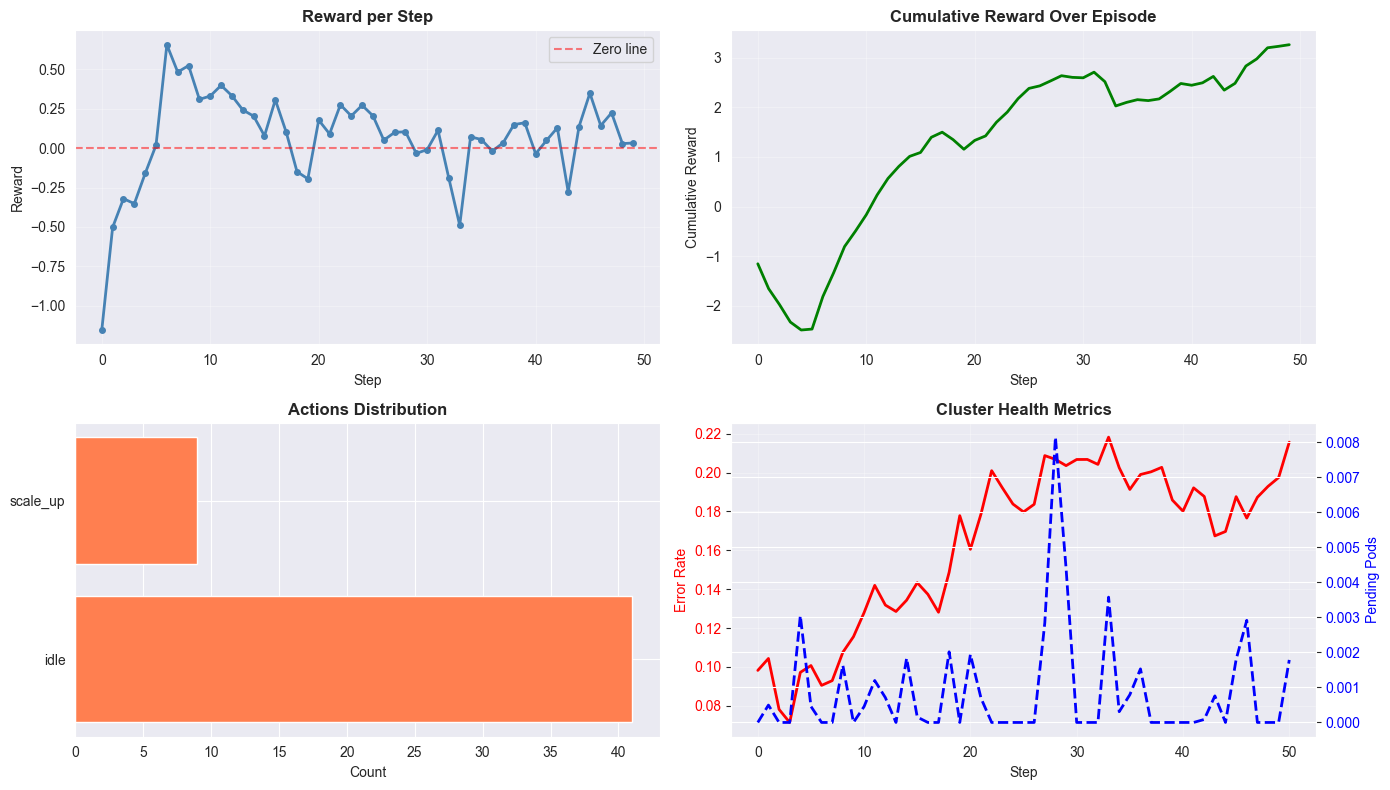

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Rollout trajectory visualization
def visualize_trajectory(agent, env, num_steps: int = 50):
    """Visualize agent's decision sequence and state evolution"""
    
    obs, _ = env.reset()
    
    actions_taken = []
    rewards_obtained = []
    states_snapshot = [obs.copy()]
    
    for _ in range(num_steps):
        action, _ = agent.predict(obs, deterministic=True)
        
        # ── FIX LỖI Ở ĐÂY ──────────────────────────────────────────────────
        # Ép kiểu action từ numpy array về số nguyên
        action_int = int(action.item() if hasattr(action, 'item') else action)
        # ───────────────────────────────────────────────────────────────────
        
        # Truyền action_int vào env.step
        obs, reward, terminated, truncated, info = env.step(action_int)
        
        # Lưu action_int thay vì action gốc để tránh lỗi khi vẽ biểu đồ
        actions_taken.append(action_int)
        rewards_obtained.append(reward)
        states_snapshot.append(obs.copy())
        
        if terminated or truncated:
            break
    
    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    # 1. Reward per step (line chart)
    axes[0, 0].plot(rewards_obtained, linewidth=2, color='steelblue', marker='o', markersize=4)
    axes[0, 0].set_title('Reward per Step', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Step')
    axes[0, 0].set_ylabel('Reward')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Zero line')
    axes[0, 0].legend()
    
    # 2. Cumulative reward
    cumulative_rewards = np.cumsum(rewards_obtained)
    axes[0, 1].plot(cumulative_rewards, linewidth=2, color='green')
    axes[0, 1].set_title('Cumulative Reward Over Episode', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Step')
    axes[0, 1].set_ylabel('Cumulative Reward')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Actions taken
    action_names = [ActionSpace.ACTIONS[a]['name'] for a in actions_taken]
    action_counts = pd.Series(action_names).value_counts()
    axes[1, 0].barh(action_counts.index, action_counts.values, color='coral')
    axes[1, 0].set_title('Actions Distribution', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Count')
    
    # 4. State trajectory (error rate + pending pods)
    states_array = np.array(states_snapshot)
    error_rate = states_array[:, 6]  # Dimension 6: error_rate_5xx
    pending_pods = states_array[:, 9]  # Dimension 9: pending_pods (normalized)
    
    ax_err = axes[1, 1]
    ax_err.plot(error_rate, label='Error Rate', color='red', linewidth=2)
    ax_err.set_ylabel('Error Rate', color='red')
    ax_err.tick_params(axis='y', labelcolor='red')
    
    ax_pods = ax_err.twinx()
    ax_pods.plot(pending_pods, label='Pending Pods (normalized)', color='blue', linewidth=2, linestyle='--')
    ax_pods.set_ylabel('Pending Pods', color='blue')
    ax_pods.tick_params(axis='y', labelcolor='blue')
    
    ax_err.set_title('Cluster Health Metrics', fontsize=12, fontweight='bold')
    ax_err.set_xlabel('Step')
    ax_err.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('rl_trajectory.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    return actions_taken, rewards_obtained

# Generate trajectory
print("Generating trajectory visualization...")
actions, rewards = visualize_trajectory(agent, env, num_steps=50)

## 9. Model Saving & Summary

In [53]:
# Save trained model
model_path = './rl_k8s_selfhealing_agent'
agent.save(model_path)
print(f"✓ Model saved to {model_path}")

# Save training summary
summary = {
    'algorithm': training_config['algorithm'],
    'total_timesteps': training_config['total_timesteps'],
    'learning_rate': training_config['learning_rate'],
    'eval_success_rate': eval_metrics['success_rate'],
    'eval_avg_recovery_steps': eval_metrics['avg_recovery_steps'],
    'eval_avg_reward': eval_metrics['avg_reward'],
}

import json
with open('./training_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key:30s}: {value:.4f}")
    else:
        print(f"{key:30s}: {value}")
print("="*60)

✓ Model saved to ./rl_k8s_selfhealing_agent

TRAINING SUMMARY
algorithm                     : PPO
total_timesteps               : 100000
learning_rate                 : 0.0008
eval_success_rate             : 0.6300
eval_avg_recovery_steps       : 33.6984
eval_avg_reward               : -23.9382


In [ ]:
# Visualization & Analysis Section
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Function to plot loss
def plot_loss(losses):
    clear_output(wait=True)
    plt.figure(figsize=(10, 5))
    plt.plot(losses, label='Loss')
    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Time')
    plt.legend()
    plt.grid()
    plt.show()

# Example usage for visualization
if __name__ == "__main__":
    # Simulated losses for demonstration
    simulated_losses = [np.random.random() for _ in range(100)]
    plot_loss(simulated_losses)